In [2]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

### 문제 1. 기초통계량 계산

In [11]:
# 데이터 생성
# 온라인 쇼핑몰 고객 1,000명을 대상으로 1점부터 10점 사이의 만족도 조사를 실시했습니다.
# 이 데이터를 바탕으로 고객 만족도의 중심 경향성과 분포 특성을 파악해 봅시다.
np.random.seed(2025)
satisfaction = np.random.normal(7.5, 1.5, 1000)
satisfaction = np.clip(satisfaction, 1, 10)
df1 = pd.DataFrame({'score': satisfaction})

#📌 아래를 수행해 보세요:

1. 평균, 중앙값, 최빈값, 표준편차를 계산해 봅시다.
2. 히스토그램을 그리고 평균과 중앙값 선으로 표시해 봅시다.
3. 데이터의 분포 형태를 해석한 후, 마케팅 전략 수립에 어떻게 활용할 수 있을지 생각해 봅시다.


In [12]:
import numpy as np

n = len(satisfaction)

# 평균 (mean) = 모든 값을 더한 후 개수로 나누기
mean_manual = sum(satisfaction) / n

# 중앙값 (median) = 정렬 후 가운데 값
sorted_scores = np.sort(satisfaction)
if n % 2 == 1:  # 홀수개
    median_manual = sorted_scores[n // 2]
else:  # 짝수개
    median_manual = (sorted_scores[n // 2 - 1] + sorted_scores[n // 2]) / 2

# 분산 (variance) - 교재 공식: 각 값과 평균의 차이를 제곱해서 더한 후 n으로 나눔
variance_manual = sum((x - mean_manual) ** 2 for x in satisfaction) / n

# 표준편차 (std) = 분산의 제곱근
std_manual = variance_manual ** 0.5

print(f"평균 (직접계산): {mean_manual:.3f}")
print(f"중앙값 (직접계산): {median_manual:.3f}")
print(f"분산 (직접계산): {variance_manual:.3f}")
print(f"표준편차 (직접계산): {std_manual:.3f}")

평균 (직접계산): 7.429
중앙값 (직접계산): 7.422
분산 (직접계산): 1.938
표준편차 (직접계산): 1.392


In [13]:
print(df1['score'].describe())

count    1000.000000
mean        7.428690
std         1.392671
min         2.724405
25%         6.469893
50%         7.421731
75%         8.437992
max        10.000000
Name: score, dtype: float64


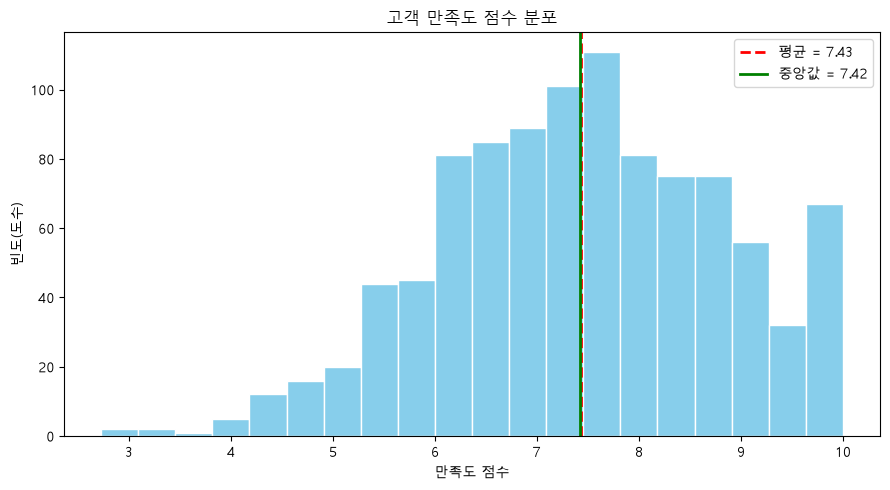

In [14]:
#히스토그램 그리기
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac이면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

mean_val = df1['score'].mean()
median_val = df1['score'].median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df1['score'], bins=20, color='skyblue', edgecolor='white')

ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'평균 = {mean_val:.2f}')
ax.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'중앙값 = {median_val:.2f}')

ax.set_title('고객 만족도 점수 분포')
ax.set_xlabel('만족도 점수')
ax.set_ylabel('빈도(도수)')
ax.legend()
plt.tight_layout()
plt.show()

### 3점-5점대 만족도를 평가한 리뷰어만 없었어도 전체적 평균은 올랐을테니 그 점수대 사람을 그냥 콱....아니다....낮게 준 사람들에게 좀더 편향된 서비스를 제공할 필요가 있지 않을까 싶은데....ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ

🧠 데이터를 어떻게 읽을까요?

▸평균과 중앙값 사이의 차이는 어느 정도인가요?
: 비슷함
▸두 값이 비슷하다면, 이 데이터는 어떤 분포 형태일 가능성이 있을까요? (예: 대칭형, 정규분포 등)
: 정규분포겠지요??게다가 중앙값과 평균값이 또 비슷하면 대칭형이다도 맞는 표현이지 않을까욥?
▸두 값의 차이가 크다면, 그 이유는 무엇일까요?
: 누군가 높거나 낮은 점수대에 평가한 리뷰어가 쏠렸다고 할 수 있겠죠?
▸어떤 값들이 평균을 끌어내리거나 끌어올렸을까요?
: 일단 먼제 10점을 준 사람들이 9점대를 준 사람보다 유의미할지는 모르지만 일단 차이를 보이고 있기에 평균을 끌어올렸을 것이다.
▸최빈값이 평균보다 낮은 경우, 낮은 점수를 준 고객이 많다는 뜻일 수 있습니다. 이 경우 데이터 분포는 어느 쪽으로 치우쳐 있을까요?
:음....꼬리가 오르쪽으로 기니까 오른쪽!
▸반대로 최빈값이 평균보다 높은 경우에는 어떤 해석이 가능할까요? 이럴 때 분포가 어떻게 달라질 수 있을까요?
높은 점수를 준 고객이 많다! 분포는 왼쪽으로 기울고 높은 점수대에 많이 분포하겠죠?
▸이 데이터를 바탕으로 고객 만족도를 높이기 위한 마케팅 전략에는 어떤 것들이 있을까요?
별5점 리뷰어 추첨 이벤트 진행해서 강제 5점 주작마케팅

# 문제 2. 평균 vs 중앙값 비교

### A지역과 B지역의 연봉 데이터를 비교해 봅시다. B 지역에는 일부 고소득자가 포함되어 있습니다.

In [15]:
# 데이터 생성
np.random.seed(2025)

# A 지역: 평균 300, 표준편차 50
region_a = np.random.normal(300, 50, 100)

# B 지역: 일반 소득자 + 극단적인 고소득자 포함
region_b = np.concatenate([
    np.random.normal(280, 40, 95),    # 일반 소득자 95명
    np.random.normal(1500, 200, 5)    # 고소득자 5명
])

df2 = pd.DataFrame({
    'region': ['A'] * 100 + ['B'] * 100,
    'salary': np.concatenate([region_a, region_b])
})

In [16]:
summary = df2.groupby('region')['salary'].agg(['mean', 'median', 'std'])
print(summary)

              mean      median         std
region                                    
A       292.506637  294.324483   46.520667
B       347.594909  287.347488  290.417556


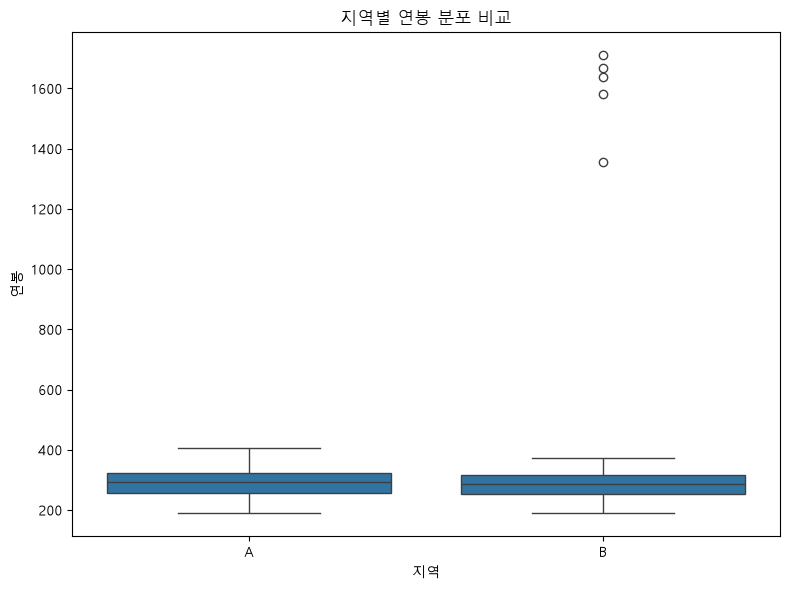

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df2, x='region', y='salary', ax=ax)
ax.set_title('지역별 연봉 분포 비교')
ax.set_xlabel('지역')
ax.set_ylabel('연봉')
plt.tight_layout()
plt.show()

### A와B의 평균연봉은 B가 50정도 높다. B지역이 A보다 조금 더 고소득자가 많다 의미 할 수 있으며, 고소득자가 평균을 끌어올린다고 할 수 있다. 중앙값은 반대로 B가 좀 낮으며 A보다 중하위층이 더 많다라고 볼 수 있다. 평균은 최솟값과 최대값의 중앙이라 볼 수 있고, 중앙값은 그냥 높은 지수를 의미함 그렇기에 극단값은 평균애 영향을 준다. 박스플롯을 통해 이상치와 사분위를 확인할 수 있다. 이상치는 동글뱅이로 B에서 5개가 그 중거다ㅏ. 사분위범위는 두 지역 모두 비슷하다. 평균은 아까도 말했듯이 최솟값, 최댓값에 영향을 받기에 하나라도 이상치가 존재시 많은 오차를 일으킨다. 그렇기에 항상 데이터는 어느정도 정제하여 사용해야한다. 본인은 새우실험 하다가 수조내에서 혼자 사료 다먹은 새우 한마리 때문에 실험 데이터가 엉망되어 곤란했던 적이 있다.ㅋ

# 문제 3. 이상값과 분산 비교
## 1반과 2반의 시험 점수 분포를 비교해 봅시다.
## 2반에는 극단적인 이상값이 포함되어 있습니다.

In [18]:
# 데이터 생성
np.random.seed(2025)  # 재현 가능성을 위해 시드 고정

# 1반: 평균 75, 표준편차 8
class1 = np.random.normal(75, 8, 30)

# 2반: 일반 학생 + 이상값(0점, 130점)
class2 = np.concatenate([
    np.random.normal(75, 15, 28),  # 일반 학생
    [0, 130]                       # 극단적인 이상값
])

df3 = pd.DataFrame({
    'class': ['1반'] * 30 + ['2반'] * 30,
    'score': np.concatenate([class1, class2])
})

In [19]:
summary = df3.groupby('class')['score'].agg(['mean', 'median', 'std', 'min', 'max'])
print(summary)

            mean     median        std        min         max
class                                                        
1반     75.724316  74.750510   7.062710  60.685416   92.175893
2반     73.728848  73.003726  22.340818   0.000000  130.000000


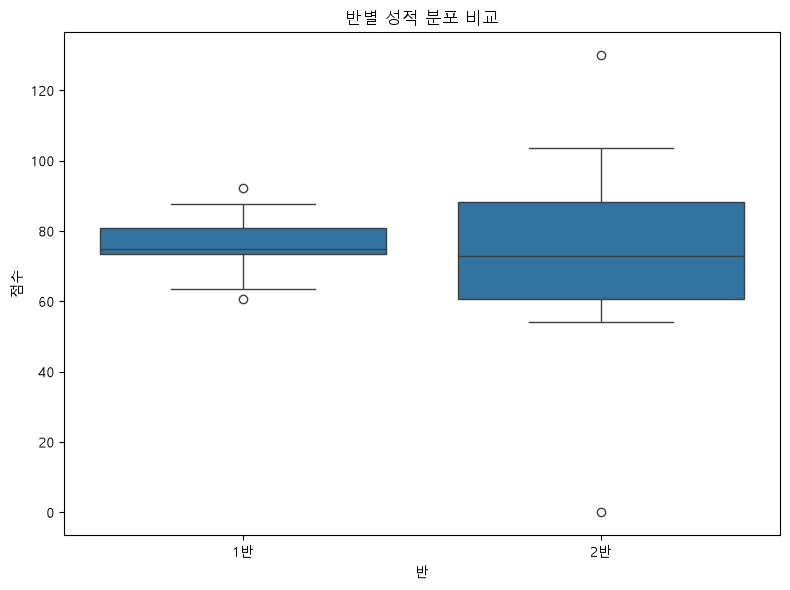

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df3, x='class', y='score', ax=ax)
ax.set_title('반별 성적 분포 비교')
ax.set_xlabel('반')
ax.set_ylabel('점수')
plt.tight_layout()
plt.show()

2반의 분산이 더 크고 표준편차와 범위, IQR을 통해 알 수 있음. 이상값이 존재하는 순간 범위 자체가 크게 늘어남. 이상값이 평균에 미친 영향은 없음. 서로 최소최대이상값이 존재하였기에 상쇄됨. 그렇다고 평균과 중앙값이 비슷해도 이상값이 없다는 것은 아님. 표준편차를 같이 봐야함. 박스플롯에서 동그랗게 이상값이 나타남. 1반은 박스가 좁고 2반은 넓음. 평균만 보면 2반이 조금 못한다로 보이지만 차이는 크지 않음. 확실한건 실력차이는 2반내에서 크다. 아주멍청이 아주 똑똑이 이렇게 너무 남.

# 문제 4. IQR 이상값 제거
## ▸
앞의 문제에서 2반에는 **극단적인 이상값(예: 매우 낮은 점수)**이 포함되어 있어 통계 지표, 특히 평균에 큰 영향을 주는 것을 확인했습니다.
▸
이번에는 **IQR(사분위 범위)**을 기준으로 이상값을 제거한 뒤, 이상값 제거 전후의 평균을 비교해 봅시다

📌 아래를 수행해 보세요:

▸
2반의 점수 데이터를 대상으로 IQR 기준을 사용해 이상값을 판별하고 제거해 봅시다.
▸
이상값 제거 전과 제거 후의 평균을 각각 계산해 봅시다.
▸
이상값 제거가 평균에 어떤 영향을 주는지 설명해 봅시다.
▸
필요하다면 중앙값과도 비교해 봅시다.

In [22]:
class2_scores = df3[df3['class'] == '2반']['score']

# IQR 계산
q1 = class2_scores.quantile(0.25)
q3 = class2_scores.quantile(0.75)
iqr = q3 - q1

# 정상 범위: Q1 - 1.5*IQR ~ Q3 + 1.5*IQR
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"정상 범위: {lower_bound:.2f} ~ {upper_bound:.2f}")

# 이상값 판별
outliers = class2_scores[(class2_scores < lower_bound) | (class2_scores > upper_bound)]
print(f"이상값: {sorted(outliers.values)}")

# 이상값 제거
class2_clean = class2_scores[(class2_scores >= lower_bound) & (class2_scores <= upper_bound)]

print(f"제거 전: 평균={class2_scores.mean():.2f}, 중앙값={class2_scores.median():.2f}, 표준편차={class2_scores.std():.2f}, n={len(class2_scores)}")
print(f"제거 후: 평균={class2_clean.mean():.2f}, 중앙값={class2_clean.median():.2f}, 표준편차={class2_clean.std():.2f}, n={len(class2_clean)}")

정상 범위: 19.33 ~ 129.79
이상값: [np.float64(0.0), np.float64(130.0)]
제거 전: 평균=73.73, 중앙값=73.00, 표준편차=22.34, n=30
제거 후: 평균=74.35, 중앙값=73.00, 표준편차=14.73, n=28


이상값 제거 전후 평균을 비교해보자면 아주 약간 상승하였다.중앙값에 가까워지 않ㄴ고 오히려 차이가 커져버림. 이상값이 양쪽에 있기에. 상쇄됨. IQR의 1.5배가 벗어나면 이상값으로 평균과 표준편차가 이에 영향을 받음. 실제로 존재하는 의미가 있는 값이면 유지하는게 맞으나 이로인해 표준편차가 커지면 유의차가 발생하여 신뢰도가 낮아질 수 있어서 최대한 안들키는 선에서 삭제하깈ㅋㅋㅋㅋㅋㅋㅋㅋㅋ제 경험담입니다욬ㅋㅋㅋ